# Astrometric before/after: raw WCS, latent head, and PINN

This notebook uses the current v8 latent-position evaluation products:

1. **Raw WCS**: per-source band position vs Euclid VIS position from `anchors.npz`.
2. **Raw + PINN field**: residual after subtracting the smooth global field fitted to raw anchors.
3. **Latent head**: per-object residual after the astrometry head correction (`*_head_resid`).
4. **Head + PINN residual field**: residual after fitting/subtracting the tiny coherent field left after the head.

The important distinction: the PINN/concordance field is a smooth WCS-level correction, while the latent head is a per-object correction. In ECDFS the smooth field is only a few mas, so the PINN field should not be expected to erase the per-source centroid scatter by itself.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from scipy.ndimage import map_coordinates

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.origin'] = 'lower'


def find_repo_root(start: Path = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'io').exists():
            return cand
    return start


ROOT = find_repo_root()
CKPT = ROOT / 'models' / 'checkpoints' / 'latent_position_v8_no_psf'
OUT_DIR = ROOT / 'io'

ANCHORS_PATH = CKPT / 'anchors.npz'
FITS_PINN_RAW = CKPT / 'concordance_pinn_raw_fixed.fits'
FITS_PINN_HEAD = CKPT / 'concordance_pinn_head_resid_fixed.fits'

for label, p in [
    ('Anchors', ANCHORS_PATH),
    ('PINN raw FITS', FITS_PINN_RAW),
    ('PINN head-resid FITS', FITS_PINN_HEAD),
]:
    print(f'{label:20s}: {p.relative_to(ROOT) if p.exists() else p}  {"OK" if p.exists() else "MISSING"}')

RUBIN_BANDS = ['u', 'g', 'r', 'i', 'z', 'y']
NISP_BANDS = ['nisp_Y', 'nisp_J', 'nisp_H']
ALL_BANDS = RUBIN_BANDS + NISP_BANDS


def display_band(band: str) -> str:
    return band.replace('nisp_', 'NISP ')


def fits_ext(band: str) -> str:
    return band.replace('nisp_', 'NISP_') if band.startswith('nisp_') else band.upper()


Anchors             : models/checkpoints/latent_position_v8_no_psf/anchors.npz  OK
PINN raw FITS       : models/checkpoints/latent_position_v8_no_psf/concordance_pinn_raw_fixed.fits  OK
PINN head-resid FITS: models/checkpoints/latent_position_v8_no_psf/concordance_pinn_head_resid_fixed.fits  OK


## 1. Load anchors and sample concordance fields

The anchor offsets are stored in arcsec. All plotted summary statistics below are converted to mas.


In [2]:
anchors = np.load(ANCHORS_PATH, allow_pickle=True)


def sample_field_at_sources(fits_path: Path, band: str, ra, dec):
    """Return [N, 2] field correction in arcsec sampled at source sky positions."""
    ext = fits_ext(band)
    with fits.open(fits_path) as hdul:
        try:
            dra_hdu = hdul[f'{ext}.DRA']
            dde_hdu = hdul[f'{ext}.DDE']
        except KeyError:
            return None
        dra_map = np.asarray(dra_hdu.data, dtype=np.float64)
        dde_map = np.asarray(dde_hdu.data, dtype=np.float64)
        w = WCS(dra_hdu.header, naxis=2)

    px, py = w.wcs_world2pix(np.asarray(ra), np.asarray(dec), 0)
    coords = np.stack([py, px], axis=0)
    dra = map_coordinates(dra_map, coords, order=1, mode='nearest')
    dde = map_coordinates(dde_map, coords, order=1, mode='nearest')
    return np.stack([dra, dde], axis=1).astype(np.float32)


def mag_mas(offset_arcsec):
    return np.hypot(offset_arcsec[:, 0], offset_arcsec[:, 1]) * 1000.0


def med_mas(offset_arcsec):
    return float(np.nanmedian(mag_mas(offset_arcsec)))


def p68_mas(offset_arcsec):
    return float(np.nanpercentile(mag_mas(offset_arcsec), 68.0))


data = {}
print(f'\n{"Band":>8} {"N":>8}  {"Raw":>8} {"Raw+PINN":>9} {"Head":>8} {"Head+PINN":>10}  {"|Fraw|":>8} {"|Fhead|":>8}')
print('-' * 88)

for band in ALL_BANDS:
    if f'{band}_raw' not in anchors or f'{band}_head_resid' not in anchors:
        print(f'{display_band(band):>8}  missing in anchors, skipping')
        continue

    ra = anchors[f'{band}_ra']
    dec = anchors[f'{band}_dec']
    raw = anchors[f'{band}_raw'].astype(np.float32)
    head = anchors[f'{band}_head_resid'].astype(np.float32)
    snr = anchors[f'{band}_snr'] if f'{band}_snr' in anchors else np.full(len(raw), np.nan, dtype=np.float32)

    raw_field = sample_field_at_sources(FITS_PINN_RAW, band, ra, dec)
    head_field = sample_field_at_sources(FITS_PINN_HEAD, band, ra, dec)

    raw_pinn = raw - raw_field if raw_field is not None else None
    head_pinn = head - head_field if head_field is not None else None

    entry = {
        'ra': ra,
        'dec': dec,
        'raw': raw,
        'head': head,
        'snr': snr,
        'raw_field': raw_field,
        'head_field': head_field,
        'raw_pinn': raw_pinn,
        'head_pinn': head_pinn,
        'n': len(raw),
    }
    data[band] = entry

    print(
        f'{display_band(band):>8} {len(raw):8d}  '
        f'{med_mas(raw):8.1f} '
        f'{med_mas(raw_pinn) if raw_pinn is not None else np.nan:9.1f} '
        f'{med_mas(head):8.1f} '
        f'{med_mas(head_pinn) if head_pinn is not None else np.nan:10.1f}  '
        f'{med_mas(raw_field) if raw_field is not None else np.nan:8.1f} '
        f'{med_mas(head_field) if head_field is not None else np.nan:8.1f}'
    )



    Band        N       Raw  Raw+PINN     Head  Head+PINN    |Fraw|  |Fhead|
----------------------------------------------------------------------------------------
       u    12347     119.4     119.2     30.5       30.3       9.2      1.1
       g    60148      54.0      53.8     11.4       11.4       4.9      0.7


       r    70022      45.7      45.6     10.4       10.4       4.9      0.8


       i    62232      41.2      41.1     10.3       10.2       5.1      0.9
       z    42980      41.9      41.7     10.9       10.8       5.0      1.0
       y    17126      61.5      60.9     14.7       14.5       5.9      1.6


  NISP Y   116572      41.3      40.7      9.4        9.4       7.3      0.9
  NISP J   126352      41.9      41.0      9.4        9.4       7.5      0.8


  NISP H   122341      42.2      41.5      9.5        9.5       7.1      0.9


## 2. Median per-source offsets

The raw PINN field is intentionally smooth, so it removes coherent WCS structure but not random centroid scatter. The latent head should be the large per-object improvement. The final residual PINN field after the head should be tiny if little coherent structure remains.


Saved io/astrometry_before_after.png
Saved io/astrometry_bar_chart.png


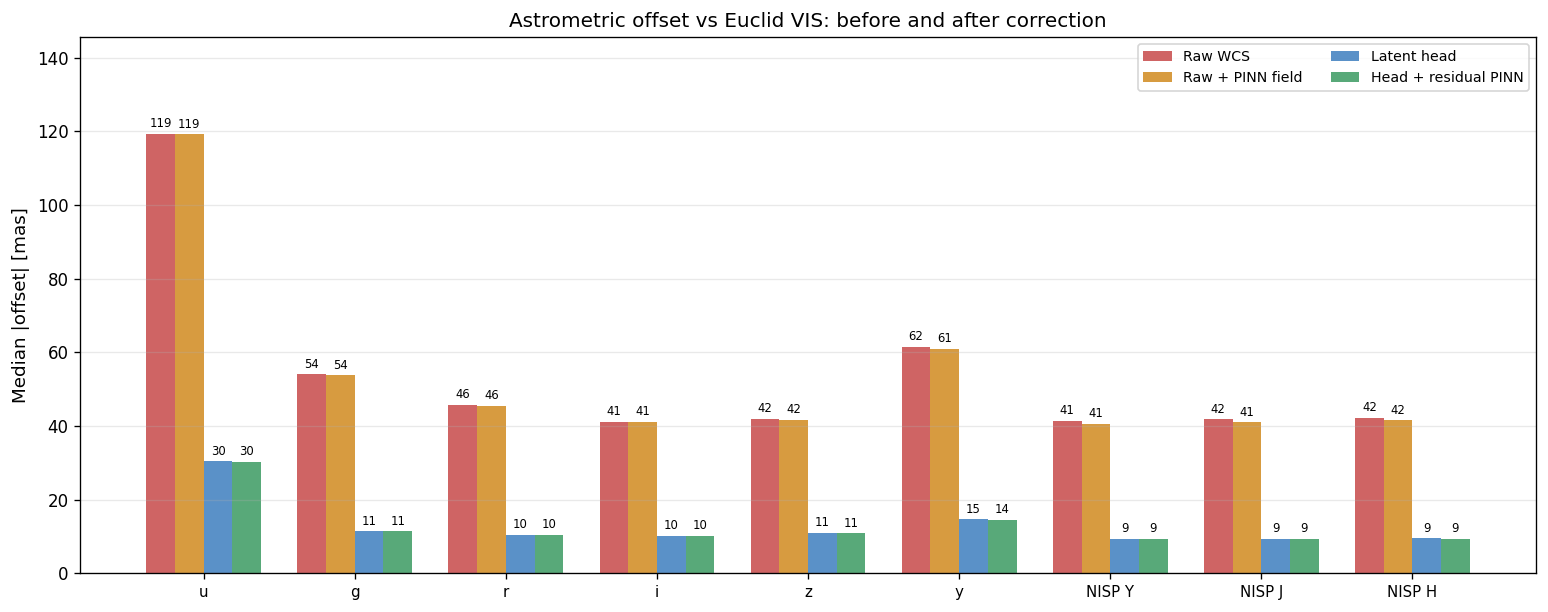


    Band        N       Raw  Raw+PINN     Head  Head+PINN   Head impr
----------------------------------------------------------------------------------
       u    12347     119.4     119.2     30.5       30.3       74.5%
       g    60148      54.0      53.8     11.4       11.4       78.9%
       r    70022      45.7      45.6     10.4       10.4       77.2%
       i    62232      41.2      41.1     10.3       10.2       75.1%
       z    42980      41.9      41.7     10.9       10.8       74.0%
       y    17126      61.5      60.9     14.7       14.5       76.2%
  NISP Y   116572      41.3      40.7      9.4        9.4       77.2%
  NISP J   126352      41.9      41.0      9.4        9.4       77.5%
  NISP H   122341      42.2      41.5      9.5        9.5       77.6%


In [3]:
bands_present = [b for b in ALL_BANDS if b in data]
x = np.arange(len(bands_present))
width = 0.19

series = [
    ('Raw WCS', 'raw', '#c84b4b'),
    ('Raw + PINN field', 'raw_pinn', '#d18b20'),
    ('Latent head', 'head', '#3f7fbf'),
    ('Head + residual PINN', 'head_pinn', '#3d9b63'),
]

values = {}
for label, key, color in series:
    vals = []
    for band in bands_present:
        arr = data[band].get(key)
        vals.append(med_mas(arr) if arr is not None else np.nan)
    values[key] = vals

fig, ax = plt.subplots(figsize=(13, 5.2))
for i, (label, key, color) in enumerate(series):
    xpos = x + (i - 1.5) * width
    bars = ax.bar(xpos, values[key], width, label=label, color=color, alpha=0.86)
    for bar, val in zip(bars, values[key]):
        if not np.isfinite(val):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.0,
            f'{val:.0f}',
            ha='center', va='bottom', fontsize=7,
        )

labels = [display_band(b) for b in bands_present]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Median |offset| [mas]', fontsize=11)
ax.set_title('Astrometric offset vs Euclid VIS: before and after correction', fontsize=12)
ax.legend(fontsize=8.5, ncol=2, loc='upper right')
ax.grid(axis='y', alpha=0.28)
ax.set_ylim(0, max(values['raw']) * 1.22)
plt.tight_layout()

out_before_after = OUT_DIR / 'astrometry_before_after.png'
out_bar = OUT_DIR / 'astrometry_bar_chart.png'
plt.savefig(out_before_after, dpi=220, bbox_inches='tight')
plt.savefig(out_bar, dpi=220, bbox_inches='tight')
print(f'Saved {out_before_after.relative_to(ROOT)}')
print(f'Saved {out_bar.relative_to(ROOT)}')
plt.show()

print(f'\n{"Band":>8} {"N":>8}  {"Raw":>8} {"Raw+PINN":>9} {"Head":>8} {"Head+PINN":>10}  {"Head impr":>10}')
print('-' * 82)
for band in bands_present:
    raw_med = med_mas(data[band]['raw'])
    raw_pinn_med = med_mas(data[band]['raw_pinn']) if data[band]['raw_pinn'] is not None else np.nan
    head_med = med_mas(data[band]['head'])
    head_pinn_med = med_mas(data[band]['head_pinn']) if data[band]['head_pinn'] is not None else np.nan
    head_impr = (1.0 - head_med / raw_med) * 100.0 if raw_med > 0 else np.nan
    print(
        f'{display_band(band):>8} {data[band]["n"]:8d}  '
        f'{raw_med:8.1f} {raw_pinn_med:9.1f} {head_med:8.1f} {head_pinn_med:10.1f}  '
        f'{head_impr:9.1f}%'
    )


## 3. Per-band distributions

These histograms show why a smooth concordance field and a per-object head are not interchangeable. The field moves the center of the distribution by a few mas; the head narrows the per-source residual distribution much more strongly.


Saved io/astrometry_histograms.png


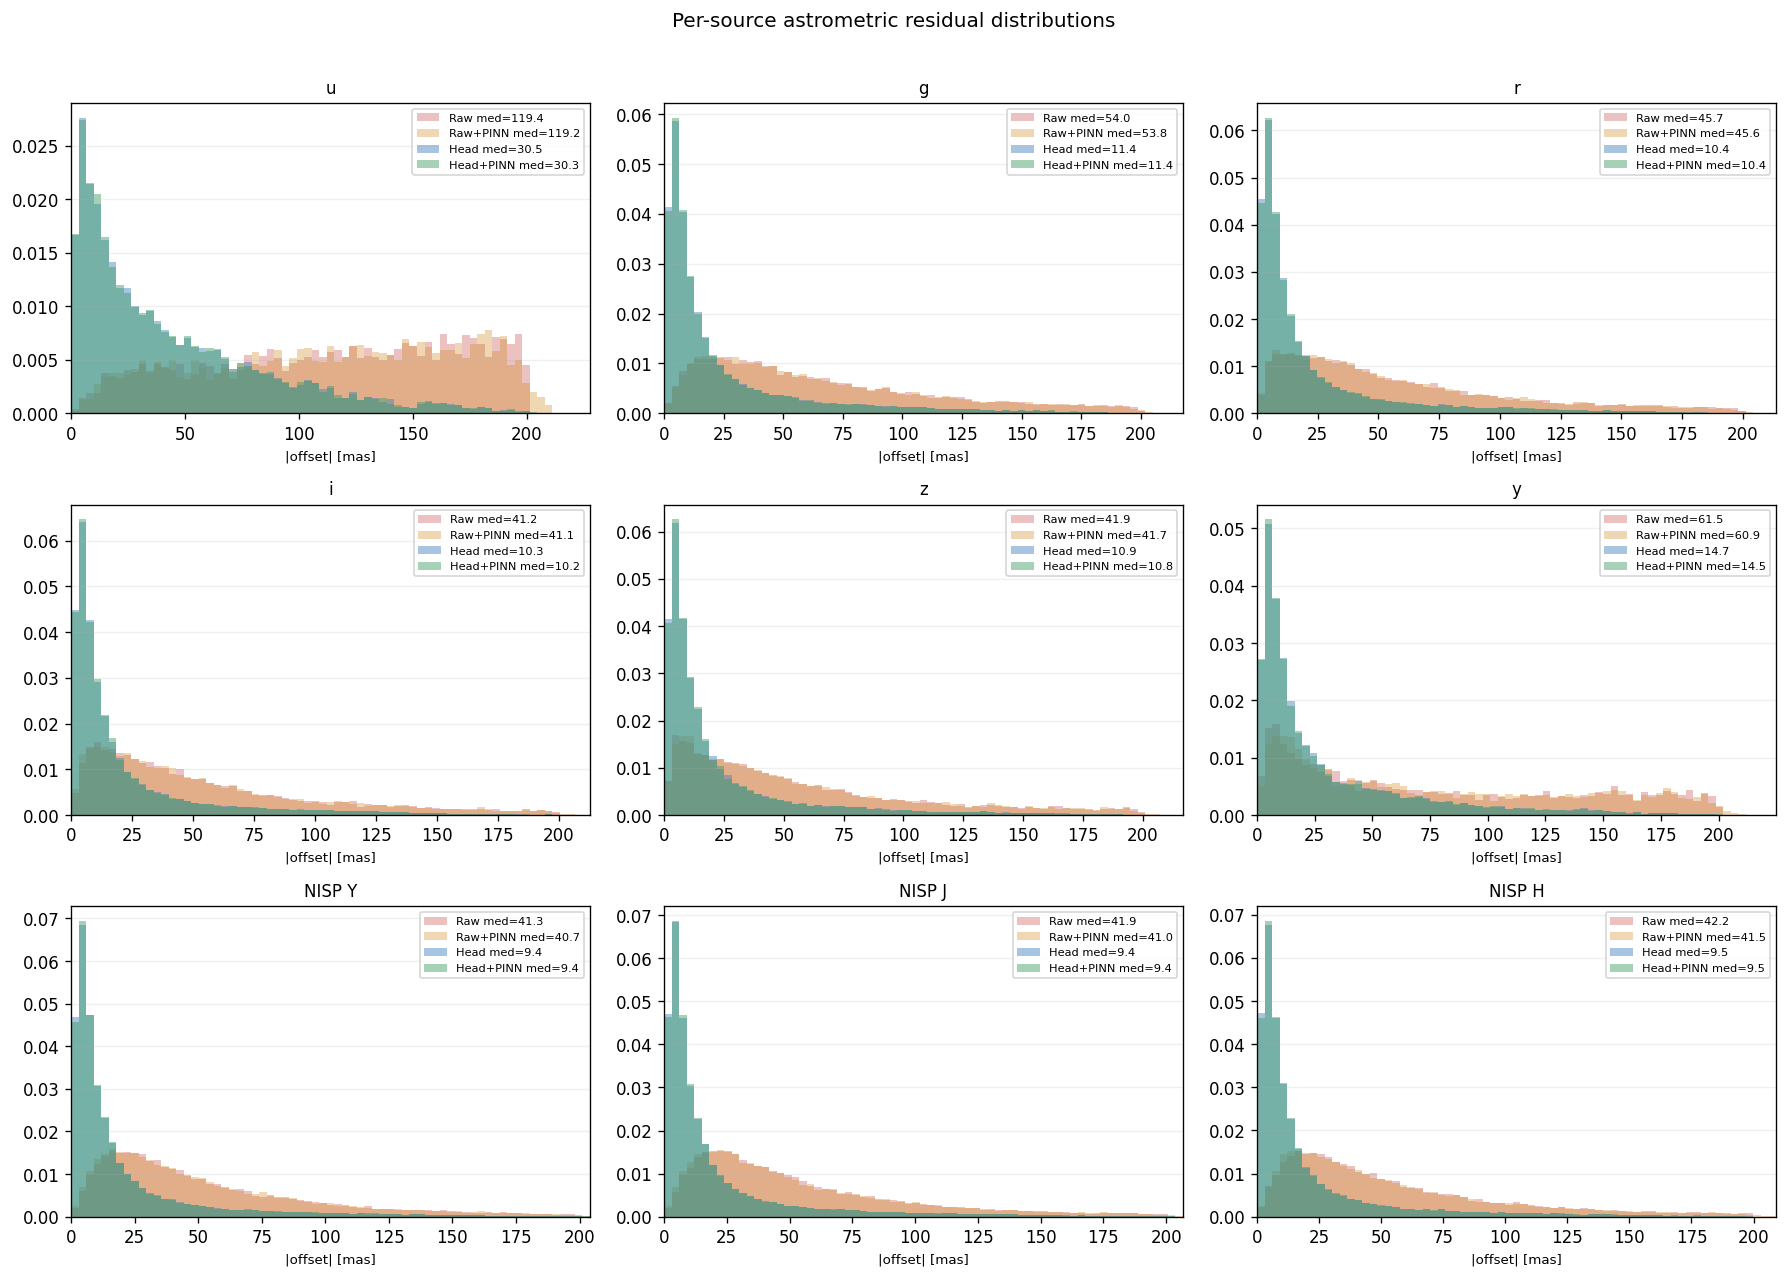

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes_flat = axes.ravel()

for idx, band in enumerate(bands_present):
    ax = axes_flat[idx]
    d = data[band]

    raw_mag = mag_mas(d['raw'])
    raw_pinn_mag = mag_mas(d['raw_pinn']) if d['raw_pinn'] is not None else None
    head_mag = mag_mas(d['head'])
    head_pinn_mag = mag_mas(d['head_pinn']) if d['head_pinn'] is not None else None

    finite_ref = raw_mag[np.isfinite(raw_mag)]
    xlim = float(np.nanpercentile(finite_ref, 98.5)) if finite_ref.size else 100.0
    xlim = max(50.0, min(240.0, xlim * 1.15))
    bins = np.linspace(0, xlim, 70)

    ax.hist(raw_mag, bins=bins, alpha=0.34, color='#c84b4b', density=True,
            label=f'Raw med={np.nanmedian(raw_mag):.1f}')
    if raw_pinn_mag is not None:
        ax.hist(raw_pinn_mag, bins=bins, alpha=0.34, color='#d18b20', density=True,
                label=f'Raw+PINN med={np.nanmedian(raw_pinn_mag):.1f}')
    ax.hist(head_mag, bins=bins, alpha=0.46, color='#3f7fbf', density=True,
            label=f'Head med={np.nanmedian(head_mag):.1f}')
    if head_pinn_mag is not None:
        ax.hist(head_pinn_mag, bins=bins, alpha=0.46, color='#3d9b63', density=True,
                label=f'Head+PINN med={np.nanmedian(head_pinn_mag):.1f}')

    ax.set_title(display_band(band), fontsize=10)
    ax.set_xlabel('|offset| [mas]', fontsize=8)
    ax.set_xlim(0, xlim)
    ax.legend(fontsize=6.8)
    ax.grid(axis='y', alpha=0.2)

for ax in axes_flat[len(bands_present):]:
    ax.axis('off')

plt.suptitle('Per-source astrometric residual distributions', fontsize=12, y=1.01)
plt.tight_layout()
out_hist = OUT_DIR / 'astrometry_histograms.png'
plt.savefig(out_hist, dpi=220, bbox_inches='tight')
print(f'Saved {out_hist.relative_to(ROOT)}')
plt.show()


## 4. Decomposed statistics

`|sys|` is the magnitude of the median vector offset. `med` and `p68` describe the radial per-source scatter. The PINN field mainly targets `|sys|`/coherent structure; the latent head targets per-object residuals.


In [5]:
def mad_sigma(x):
    return 1.4826 * np.nanmedian(np.abs(x - np.nanmedian(x)))


def vector_stats(arr_arcsec):
    arr_mas = np.asarray(arr_arcsec) * 1000.0
    mag = np.hypot(arr_mas[:, 0], arr_mas[:, 1])
    sys = np.hypot(np.nanmedian(arr_mas[:, 0]), np.nanmedian(arr_mas[:, 1]))
    return {
        'sys': float(sys),
        'med': float(np.nanmedian(mag)),
        'p68': float(np.nanpercentile(mag, 68.0)),
        'mad_ra': float(mad_sigma(arr_mas[:, 0])),
        'mad_de': float(mad_sigma(arr_mas[:, 1])),
    }

columns = [
    ('Raw', 'raw'),
    ('Raw+PINN', 'raw_pinn'),
    ('Head', 'head'),
    ('Head+PINN', 'head_pinn'),
]

print(f'{"Band":>8} {"N":>8}  ' + '  '.join(f'{name:^25s}' for name, _ in columns))
print(f'{"":>8} {"":>8}  ' + '  '.join(f'{"|sys|":>6} {"med":>6} {"p68":>6} {"MADxy":>6}' for _ in columns))
print('-' * 128)

for band in bands_present:
    pieces = []
    for _, key in columns:
        arr = data[band].get(key)
        if arr is None:
            pieces.append(f'{np.nan:6.1f} {np.nan:6.1f} {np.nan:6.1f} {np.nan:6.1f}')
            continue
        st = vector_stats(arr)
        madxy = 0.5 * (st['mad_ra'] + st['mad_de'])
        pieces.append(f'{st["sys"]:6.1f} {st["med"]:6.1f} {st["p68"]:6.1f} {madxy:6.1f}')
    print(f'{display_band(band):>8} {data[band]["n"]:8d}  ' + '  '.join(pieces))

print('\n|sys| = magnitude of median RA/Dec residual vector [mas]')
print('med/p68 = radial per-source residual magnitude [mas]')
print('MADxy = average robust 1D component scatter [mas]')


    Band        N             Raw                     Raw+PINN                     Head                     Head+PINN        
                    |sys|    med    p68  MADxy   |sys|    med    p68  MADxy   |sys|    med    p68  MADxy   |sys|    med    p68  MADxy
--------------------------------------------------------------------------------------------------------------------------------
       u    12347    10.2  119.4  150.9   94.8     7.2  119.2  150.1   94.3     0.4   30.5   53.3   21.5     0.2   30.3   53.3   21.5
       g    60148     3.8   54.0   81.0   44.0     0.7   53.8   80.8   44.0     0.5   11.4   22.3    9.4     0.2   11.4   22.3    9.4
       r    70022     3.7   45.7   71.3   36.9     0.3   45.6   70.9   37.0     0.6   10.4   19.8    8.7     0.1   10.4   19.7    8.7
       i    62232     4.5   41.2   64.3   32.7     0.8   41.1   64.4   32.9     0.6   10.3   18.9    8.4     0.1   10.2   18.8    8.5
       z    42980     3.6   41.9   66.6   33.3     1.1   41.7   66.6   33.1

## Reading the result

For ECDFS, the smooth concordance signal is small compared with per-source centroid noise. That is why `Raw + PINN field` is close to `Raw WCS` in median per-source scatter. The latent head is the large before/after improvement. The `Head + residual PINN` column is a diagnostic: if it is nearly identical to `Head`, then the head has already removed almost all coherent structure available in these anchors.
